# Cadence Frequency Analysis

Port of the web app's FFT-based pedaling detection to Python for visualization and tuning.

**Problem**: Pedaling detection during descents is broken — road vibration creates broadband noise that triggers false positives or masks real pedaling.

**What this notebook does**:
1. Ports the exact TS algorithms (HPF, DFT, 3-method confidence) to Python for validation
2. Visualizes frequency spectra to see what the algorithm "sees"
3. Compares pedaling vs descent segments side-by-side
4. Shows rolling spectrogram and confidence over time
5. Provides a tuning sandbox to test threshold changes

**Usage**: Set `VTX_FILE` and segment ranges in the config cell, then Run All.

## Section 1: Setup & Data Loading

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal

sys.path.insert(0, os.path.join(os.getcwd(), '../scripts'))
from load_vtx import load_vtx_file

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
# ============================================
# USER CONFIG — Set these before running
# ============================================

VTX_FILE = '../data/sample-recordings/thursdays_2_12_26.vtx'

# Segment ranges (seconds) — set after viewing Section 2 time series
# Each is a (start, end) tuple in seconds
SEGMENT_PEDALING_FLAT = (30, 60)       # Known pedaling on flat ground
SEGMENT_DESCENT = (120, 180)            # Descent without pedaling
SEGMENT_PEDALING_DESCENT = (200, 240)   # Pedaling during descent (if exists)

# ============================================
# ALGORITHM CONSTANTS (exact match to TS)
# From: web/src/lib/analysis/pedaling-efficiency-constants.ts
# ============================================

HPF_CUTOFF_HZ = 0.5
FFT_WINDOW_SECONDS = 10
EFFICIENCY_WINDOW_SECONDS = 3
USE_MAGNITUDE = True

CONFIDENCE_THRESHOLD = 0.15
STATIONARY_THRESHOLD = 0.15

MIN_CADENCE_RPM = 40
MAX_CADENCE_RPM = 130
MIN_FFT_SAMPLES = 32
MIN_FFT_FREQUENCY_HZ = 0.1

# Method 1: Strong periodic signal (road cycling)
METHOD_1_PEAK_TO_MEDIAN = 2.5
METHOD_1_MIN_STDDEV = 0.15
METHOD_1_STRONG_PEAK_THRESHOLD = 5.0
METHOD_1_STRONG_PEAK_BONUS = 0.2

# Method 2: Moderate signal (mountain biking)
METHOD_2_PEAK_TO_MEDIAN = 1.5
METHOD_2_MIN_STDDEV = 0.2
METHOD_2_MIN_CADENCE = 50
METHOD_2_MAX_CADENCE = 110
METHOD_2_MAX_CONFIDENCE = 0.6

# Method 3: High variance, weak peak (rough terrain)
METHOD_3_PEAK_TO_MEDIAN = 2.0
METHOD_3_MIN_STDDEV = 0.5
METHOD_3_MIN_CADENCE = 40
METHOD_3_MAX_CADENCE = 120
METHOD_3_MAX_CONFIDENCE = 0.4

# Efficiency formula
EFFICIENCY_DECAY_CONSTANT = 0.18
EFFICIENCY_FLOOR = 0.15
RESCALE_MIN = 0.30
RESCALE_MAX = 1.00

# Riding position
Y_AXIS_STANDING_THRESHOLD = 2.5
POSITION_WINDOW_SECONDS = 3

In [3]:
# Load VTX file
data = load_vtx_file(VTX_FILE)
header = data['header']
df = data['samples']
sample_rate = header['computed_sample_rate']

# Compute acceleration magnitude
df['accel_mag'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)

print(f"File: {VTX_FILE}")
print(f"Duration: {header['duration']:.1f}s ({header['duration']/60:.1f} min)")
print(f"Sample rate: {sample_rate:.1f} Hz")
print(f"Samples: {len(df):,}")
print(f"Time range: {df['time_sec'].iloc[0]:.1f}s — {df['time_sec'].iloc[-1]:.1f}s")
print(f"\nAccel magnitude — mean: {df['accel_mag'].mean():.2f}, std: {df['accel_mag'].std():.2f} m/s²")

File: ../data/sample-recordings/thursdays_2_12_26.vtx
Duration: 7292.3s (121.5 min)
Sample rate: 20.0 Hz
Samples: 145,639
Time range: 0.0s — 7292.3s

Accel magnitude — mean: 10.44, std: 3.14 m/s²


## Section 2: Signal Overview & Segment Picker

Use these plots to identify time ranges, then go back and set `SEGMENT_*` variables in the config cell.

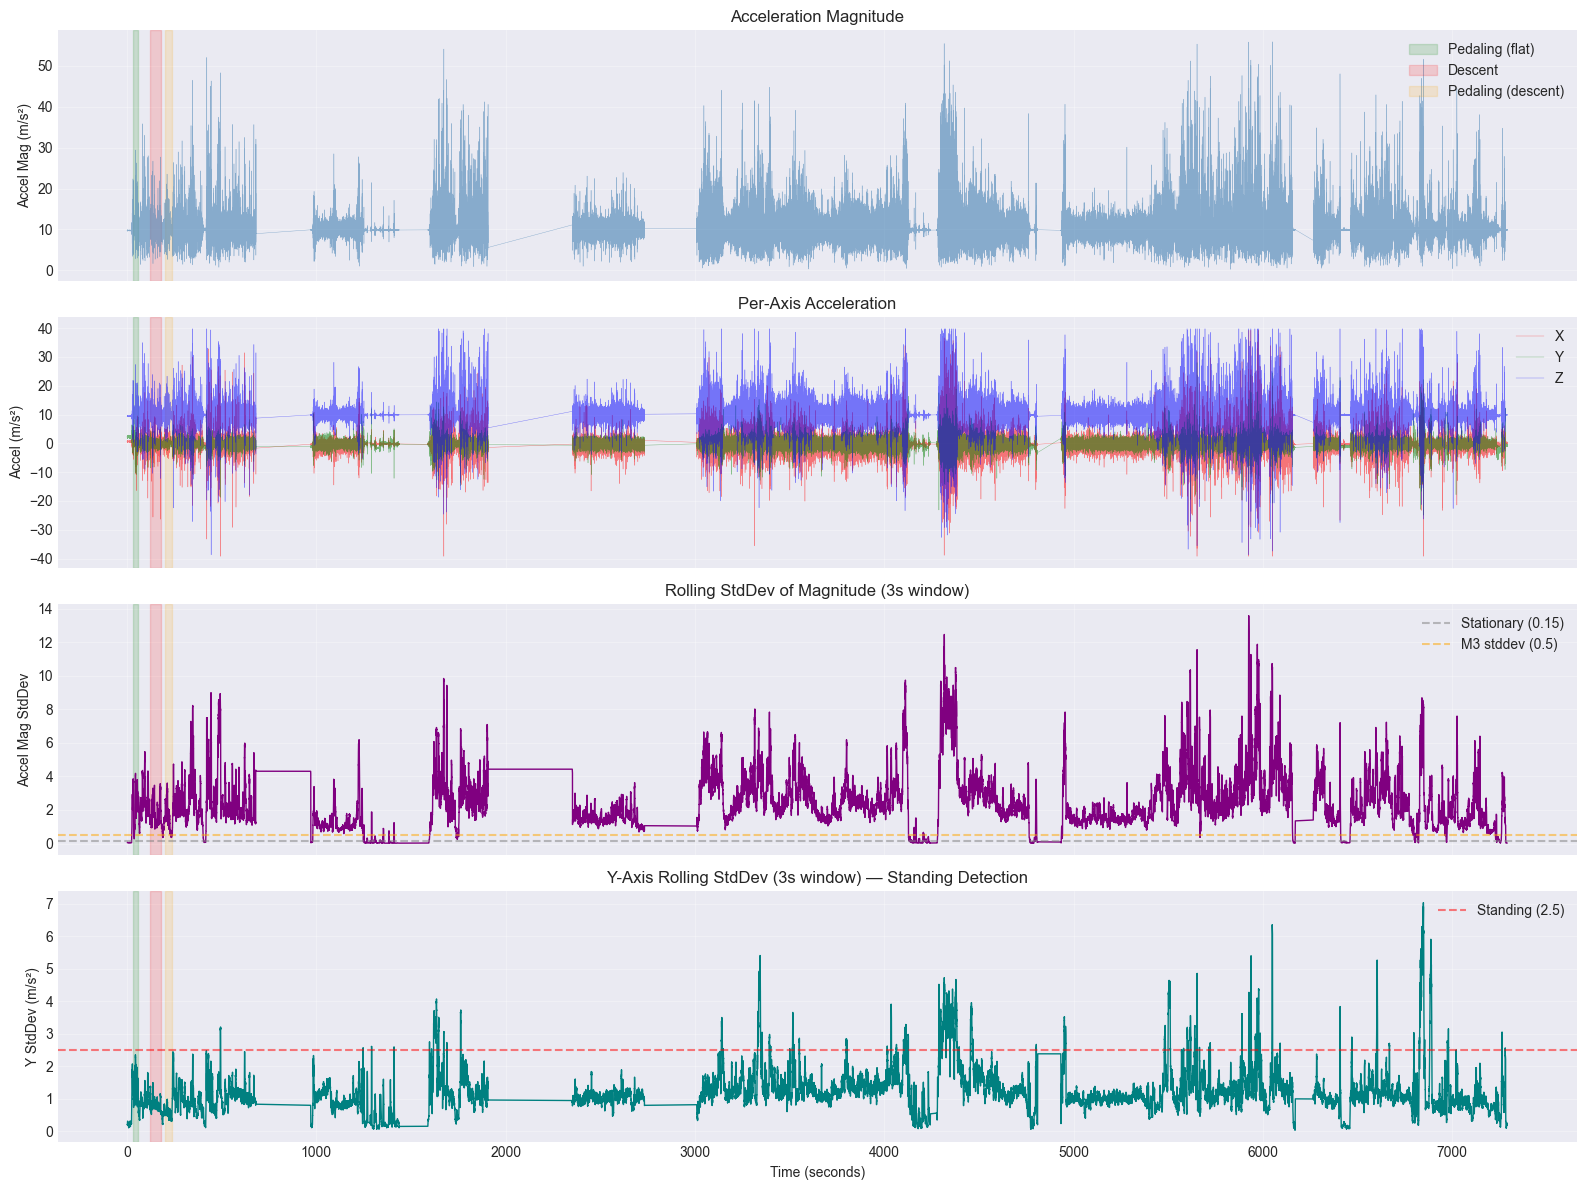

In [10]:
# Rolling standard deviation (3-second window, matches EFFICIENCY_WINDOW_SECONDS)
win = int(EFFICIENCY_WINDOW_SECONDS * sample_rate)
df['accel_mag_std'] = df['accel_mag'].rolling(win, center=True).std()
df['accel_y_std'] = df['accel_y'].rolling(win, center=True).std()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

segments = [
    (SEGMENT_PEDALING_FLAT, 'green', 'Pedaling (flat)'),
    (SEGMENT_DESCENT, 'red', 'Descent'),
    (SEGMENT_PEDALING_DESCENT, 'orange', 'Pedaling (descent)'),
]

# Panel 1: Accel magnitude
axes[0].plot(df['time_sec'], df['accel_mag'], linewidth=0.3, alpha=0.6, color='steelblue')
axes[0].set_ylabel('Accel Mag (m/s²)')
axes[0].set_title('Acceleration Magnitude')

# Panel 2: Per-axis acceleration
for axis, color in zip(['x', 'y', 'z'], ['red', 'green', 'blue']):
    axes[1].plot(df['time_sec'], df[f'accel_{axis}'], linewidth=0.3, alpha=0.5, color=color, label=axis.upper())
axes[1].set_ylabel('Accel (m/s²)')
axes[1].set_title('Per-Axis Acceleration')
axes[1].legend(loc='upper right')

# Panel 3: Rolling stddev of magnitude
axes[2].plot(df['time_sec'], df['accel_mag_std'], linewidth=1, color='purple')
axes[2].axhline(y=STATIONARY_THRESHOLD, color='gray', linestyle='--', alpha=0.5, label=f'Stationary ({STATIONARY_THRESHOLD})')
axes[2].axhline(y=METHOD_3_MIN_STDDEV, color='orange', linestyle='--', alpha=0.5, label=f'M3 stddev ({METHOD_3_MIN_STDDEV})')
axes[2].set_ylabel('Accel Mag StdDev')
axes[2].set_title(f'Rolling StdDev of Magnitude ({EFFICIENCY_WINDOW_SECONDS}s window)')
axes[2].legend(loc='upper right')

# Panel 4: Y-axis stddev (lateral rocking for position detection)
axes[3].plot(df['time_sec'], df['accel_y_std'], linewidth=1, color='teal')
axes[3].axhline(y=Y_AXIS_STANDING_THRESHOLD, color='red', linestyle='--', alpha=0.5, label=f'Standing ({Y_AXIS_STANDING_THRESHOLD})')
axes[3].set_ylabel('Y StdDev (m/s²)')
axes[3].set_xlabel('Time (seconds)')
axes[3].set_title(f'Y-Axis Rolling StdDev ({EFFICIENCY_WINDOW_SECONDS}s window) — Standing Detection')
axes[3].legend(loc='upper right')

# Shade segments on all panels
for ax in axes:
    for (start, end), color, label in segments:
        ax.axvspan(start, end, alpha=0.15, color=color, label=label if ax == axes[0] else None)
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

## Section 3: Algorithm Port (exact TS functions)

These are 1:1 ports of the TypeScript functions for validation.

In [11]:
def ema_high_pass_filter(signal_data, cutoff_hz, sample_rate):
    """
    EMA-based high-pass filter — exact port of TS HighPassFilter class.
    HPF(x) = x - LPF(x), where LPF is EMA with alpha = dt/(RC+dt), RC = 1/(2*pi*fc)
    """
    dt = 1.0 / sample_rate
    RC = 1.0 / (2.0 * np.pi * cutoff_hz)
    alpha = dt / (RC + dt)

    output = np.zeros(len(signal_data))
    lpf_value = None

    for i in range(len(signal_data)):
        if lpf_value is None:
            lpf_value = signal_data[i]
        else:
            lpf_value = alpha * signal_data[i] + (1 - alpha) * lpf_value
        output[i] = signal_data[i] - lpf_value

    return output


def compute_cadence_dft(signal_data, sample_rate, min_cadence=MIN_CADENCE_RPM, max_cadence=MAX_CADENCE_RPM):
    """
    Naive O(N^2) DFT — exact port of TS computeFrequencySpectrum().
    Only computes bins in cadence range. For validation only.
    """
    N = len(signal_data)
    min_freq = min_cadence / 60.0
    max_freq = max_cadence / 60.0

    freqs = []
    powers = []

    for k in range(N // 2):
        freq = k * sample_rate / N
        if freq < MIN_FFT_FREQUENCY_HZ or freq < min_freq or freq > max_freq:
            continue

        real = 0.0
        imag = 0.0
        for n in range(N):
            angle = -2.0 * np.pi * k * n / N
            real += signal_data[n] * np.cos(angle)
            imag += signal_data[n] * np.sin(angle)

        power = np.sqrt(real * real + imag * imag) / N
        freqs.append(freq)
        powers.append(power)

    return np.array(freqs), np.array(powers)


def compute_cadence_dft_fast(signal_data, sample_rate, min_cadence=MIN_CADENCE_RPM, max_cadence=MAX_CADENCE_RPM):
    """
    numpy rfft with cadence-band mask. Used for rolling analysis.
    Returns same freq/power format as compute_cadence_dft.
    """
    N = len(signal_data)
    fft_vals = np.fft.rfft(signal_data)
    freqs_all = np.fft.rfftfreq(N, d=1.0 / sample_rate)
    # Magnitude normalized same as TS: sqrt(re^2 + im^2) / N
    powers_all = np.abs(fft_vals) / N

    min_freq = min_cadence / 60.0
    max_freq = max_cadence / 60.0
    mask = (freqs_all >= max(MIN_FFT_FREQUENCY_HZ, min_freq)) & (freqs_all <= max_freq)

    return freqs_all[mask], powers_all[mask]


def analyze_spectrum_stats(freqs, powers):
    """
    Exact port of TS analyzeSpectrum().
    Returns peak_idx, peak_power, median_power, avg_power.
    """
    if len(powers) == 0:
        return 0, 0.0, 0.0, 0.0

    peak_idx = int(np.argmax(powers))
    peak_power = powers[peak_idx]
    avg_power = np.mean(powers)
    sorted_powers = np.sort(powers)
    median_power = sorted_powers[len(sorted_powers) // 2]

    return peak_idx, peak_power, median_power, avg_power


def calculate_confidence(peak_to_median, stddev, cadence):
    """
    Exact port of TS calculateConfidence(). Returns (confidence, method_name).
    """
    # Method 1: Strong periodic signal
    if peak_to_median > METHOD_1_PEAK_TO_MEDIAN and stddev > METHOD_1_MIN_STDDEV:
        confidence = min(1.0, (peak_to_median - METHOD_1_PEAK_TO_MEDIAN) / 3.0)
        if peak_to_median > METHOD_1_STRONG_PEAK_THRESHOLD:
            confidence = min(1.0, confidence + METHOD_1_STRONG_PEAK_BONUS)
        return confidence, 'M1_road'

    # Method 2: Moderate signal + reasonable cadence
    if (peak_to_median > METHOD_2_PEAK_TO_MEDIAN and
            stddev > METHOD_2_MIN_STDDEV and
            cadence is not None and
            METHOD_2_MIN_CADENCE <= cadence <= METHOD_2_MAX_CADENCE):
        confidence = min(METHOD_2_MAX_CONFIDENCE, (peak_to_median - METHOD_2_PEAK_TO_MEDIAN) / 2.0)
        return confidence, 'M2_mtb'

    # Method 3: High variance, any reasonable peak
    if (stddev > METHOD_3_MIN_STDDEV and
            peak_to_median > METHOD_3_PEAK_TO_MEDIAN and
            cadence is not None and
            METHOD_3_MIN_CADENCE <= cadence <= METHOD_3_MAX_CADENCE):
        confidence = min(METHOD_3_MAX_CONFIDENCE, (peak_to_median - METHOD_3_PEAK_TO_MEDIAN) / 2.0)
        return confidence, 'M3_rough'

    return 0.0, 'none'


def calculate_efficiency(stddev):
    """
    Exact port of efficiency formula: exp(-k * stddev) with floor + rescaling.
    """
    raw = np.exp(-EFFICIENCY_DECAY_CONSTANT * stddev)
    raw = max(EFFICIENCY_FLOOR, raw)
    # Rescale [EFFICIENCY_FLOOR, 1.0] -> [RESCALE_MIN, RESCALE_MAX]
    rescaled = RESCALE_MIN + (raw - EFFICIENCY_FLOOR) / (1.0 - EFFICIENCY_FLOOR) * (RESCALE_MAX - RESCALE_MIN)
    return np.clip(rescaled, RESCALE_MIN, RESCALE_MAX)


def run_pipeline(signal_data, sample_rate, use_fast_dft=True):
    """
    Full pedaling detection pipeline on a signal segment.
    Returns dict with all intermediate values.
    """
    # Variance / stddev check
    variance = np.mean(signal_data ** 2)
    stddev = np.sqrt(variance)

    if stddev < STATIONARY_THRESHOLD:
        return {'stddev': stddev, 'confidence': 0.0, 'cadence': None, 'method': 'stationary',
                'peak_to_median': 0.0, 'peak_power': 0.0, 'median_power': 0.0, 'avg_power': 0.0,
                'efficiency': calculate_efficiency(stddev)}

    if len(signal_data) < MIN_FFT_SAMPLES:
        return {'stddev': stddev, 'confidence': 0.0, 'cadence': None, 'method': 'too_few_samples',
                'peak_to_median': 0.0, 'peak_power': 0.0, 'median_power': 0.0, 'avg_power': 0.0,
                'efficiency': calculate_efficiency(stddev)}

    # DFT in cadence band
    dft_fn = compute_cadence_dft_fast if use_fast_dft else compute_cadence_dft
    freqs, powers = dft_fn(signal_data, sample_rate)

    if len(freqs) == 0:
        return {'stddev': stddev, 'confidence': 0.0, 'cadence': None, 'method': 'no_spectrum',
                'peak_to_median': 0.0, 'peak_power': 0.0, 'median_power': 0.0, 'avg_power': 0.0,
                'efficiency': calculate_efficiency(stddev)}

    peak_idx, peak_power, median_power, avg_power = analyze_spectrum_stats(freqs, powers)
    peak_to_median = peak_power / median_power if median_power > 0 else 0.0
    cadence = freqs[peak_idx] * 60.0 if peak_idx < len(freqs) else None
    confidence, method = calculate_confidence(peak_to_median, stddev, cadence)
    efficiency = calculate_efficiency(stddev)

    return {
        'stddev': stddev, 'confidence': confidence, 'cadence': cadence, 'method': method,
        'peak_to_median': peak_to_median, 'peak_power': peak_power,
        'median_power': median_power, 'avg_power': avg_power,
        'efficiency': efficiency, 'freqs': freqs, 'powers': powers,
    }

print('Algorithm functions defined.')

Algorithm functions defined.


In [12]:
# Apply HPF to full recording (used by all downstream sections)
hpf_mag = ema_high_pass_filter(df['accel_mag'].values, HPF_CUTOFF_HZ, sample_rate)
hpf_x = ema_high_pass_filter(df['accel_x'].values, HPF_CUTOFF_HZ, sample_rate)
hpf_y = ema_high_pass_filter(df['accel_y'].values, HPF_CUTOFF_HZ, sample_rate)
hpf_z = ema_high_pass_filter(df['accel_z'].values, HPF_CUTOFF_HZ, sample_rate)

df['hpf_mag'] = hpf_mag
df['hpf_x'] = hpf_x
df['hpf_y'] = hpf_y
df['hpf_z'] = hpf_z

print(f'HPF applied (cutoff={HPF_CUTOFF_HZ} Hz). HPF magnitude std: {np.std(hpf_mag):.3f} m/s²')

HPF applied (cutoff=0.5 Hz). HPF magnitude std: 2.684 m/s²


In [13]:
# Validation: run full pipeline on SEGMENT_PEDALING_FLAT
def get_segment_hpf(seg, signal=hpf_mag):
    """Extract HPF'd signal for a time segment."""
    mask = (df['time_sec'] >= seg[0]) & (df['time_sec'] < seg[1])
    return signal[mask.values]

seg_signal = get_segment_hpf(SEGMENT_PEDALING_FLAT)
print(f'Segment: {SEGMENT_PEDALING_FLAT[0]}s–{SEGMENT_PEDALING_FLAT[1]}s ({len(seg_signal)} samples)')

# Run with both DFT methods for cross-validation
result_naive = run_pipeline(seg_signal, sample_rate, use_fast_dft=False)
result_fast = run_pipeline(seg_signal, sample_rate, use_fast_dft=True)

print(f'\n--- Naive DFT ---')
print(f'  Cadence:        {result_naive["cadence"]:.1f} RPM' if result_naive['cadence'] else '  Cadence:        None')
print(f'  Confidence:     {result_naive["confidence"]:.3f}')
print(f'  Method:         {result_naive["method"]}')
print(f'  Peak/Median:    {result_naive["peak_to_median"]:.2f}')
print(f'  StdDev:         {result_naive["stddev"]:.3f} m/s²')
print(f'  Efficiency:     {result_naive["efficiency"]:.1%}')

print(f'\n--- Fast DFT (rfft) ---')
print(f'  Cadence:        {result_fast["cadence"]:.1f} RPM' if result_fast['cadence'] else '  Cadence:        None')
print(f'  Confidence:     {result_fast["confidence"]:.3f}')
print(f'  Method:         {result_fast["method"]}')
print(f'  Peak/Median:    {result_fast["peak_to_median"]:.2f}')

if result_naive['cadence'] and result_fast['cadence']:
    diff = abs(result_naive['cadence'] - result_fast['cadence'])
    print(f'\nCadence difference: {diff:.2f} RPM ({"OK" if diff < 2 else "MISMATCH"})')

Segment: 30s–60s (744 samples)

--- Naive DFT ---
  Cadence:        96.6 RPM
  Confidence:     0.041
  Method:         M1_road
  Peak/Median:    2.62
  StdDev:         2.259 m/s²
  Efficiency:     72.5%

--- Fast DFT (rfft) ---
  Cadence:        96.6 RPM
  Confidence:     0.041
  Method:         M1_road
  Peak/Median:    2.62

Cadence difference: 0.00 RPM (OK)


## Section 4: Full-File Frequency Spectrum

Welch PSD of the entire recording for each axis + HPF magnitude.

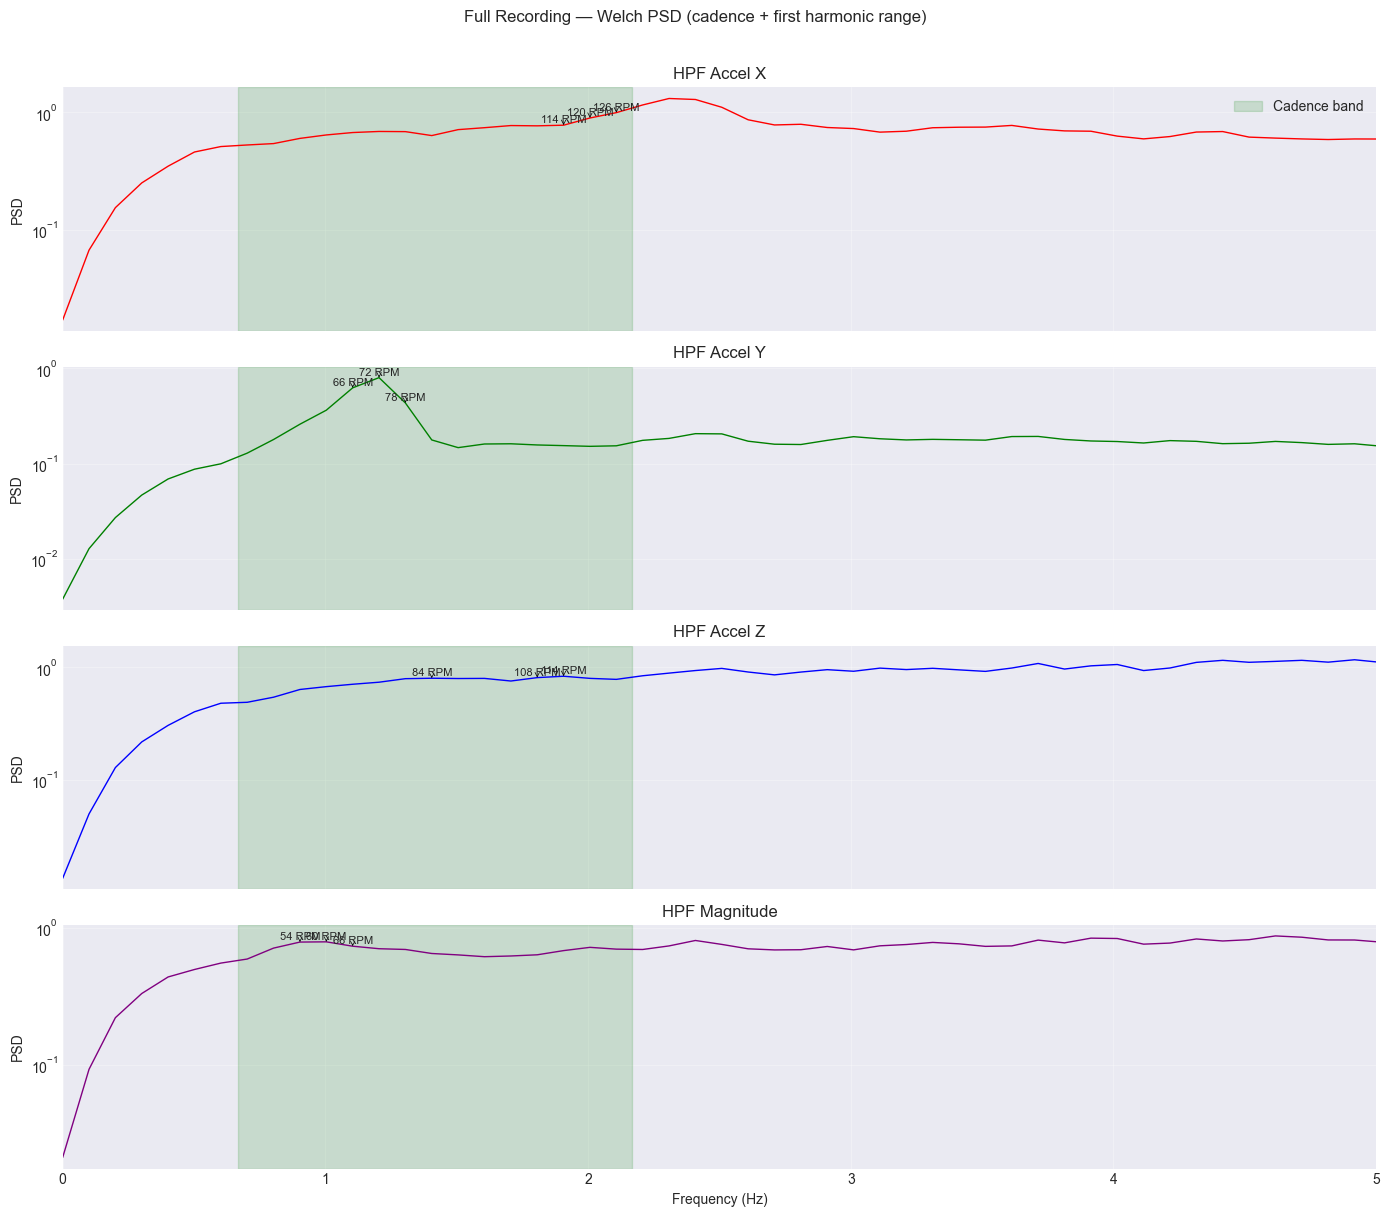

In [14]:
cadence_band = (MIN_CADENCE_RPM / 60.0, MAX_CADENCE_RPM / 60.0)  # Hz

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
nperseg = int(FFT_WINDOW_SECONDS * sample_rate)

signals_and_labels = [
    (df['hpf_x'].values, 'HPF Accel X', 'red'),
    (df['hpf_y'].values, 'HPF Accel Y', 'green'),
    (df['hpf_z'].values, 'HPF Accel Z', 'blue'),
    (df['hpf_mag'].values, 'HPF Magnitude', 'purple'),
]

for ax, (sig, label, color) in zip(axes, signals_and_labels):
    f, Pxx = scipy_signal.welch(sig, fs=sample_rate, nperseg=nperseg, noverlap=nperseg // 2)
    ax.semilogy(f, Pxx, color=color, linewidth=1)
    ax.axvspan(cadence_band[0], cadence_band[1], alpha=0.15, color='green', label='Cadence band')
    ax.set_ylabel('PSD')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

    # Annotate top 3 peaks in cadence band
    band_mask = (f >= cadence_band[0]) & (f <= cadence_band[1])
    if np.any(band_mask):
        f_band, Pxx_band = f[band_mask], Pxx[band_mask]
        top_idx = np.argsort(Pxx_band)[-3:][::-1]
        for idx in top_idx:
            ax.annotate(f'{f_band[idx]*60:.0f} RPM',
                        xy=(f_band[idx], Pxx_band[idx]),
                        fontsize=8, ha='center', va='bottom',
                        arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

axes[-1].set_xlabel('Frequency (Hz)')
axes[0].set_xlim(0, 5)
axes[0].legend(loc='upper right')
plt.suptitle('Full Recording — Welch PSD (cadence + first harmonic range)', y=1.01)
plt.tight_layout()
plt.show()

## Section 5: Segment Frequency Comparison

Key diagnostic: does descent show broadband noise or a false cadence peak?

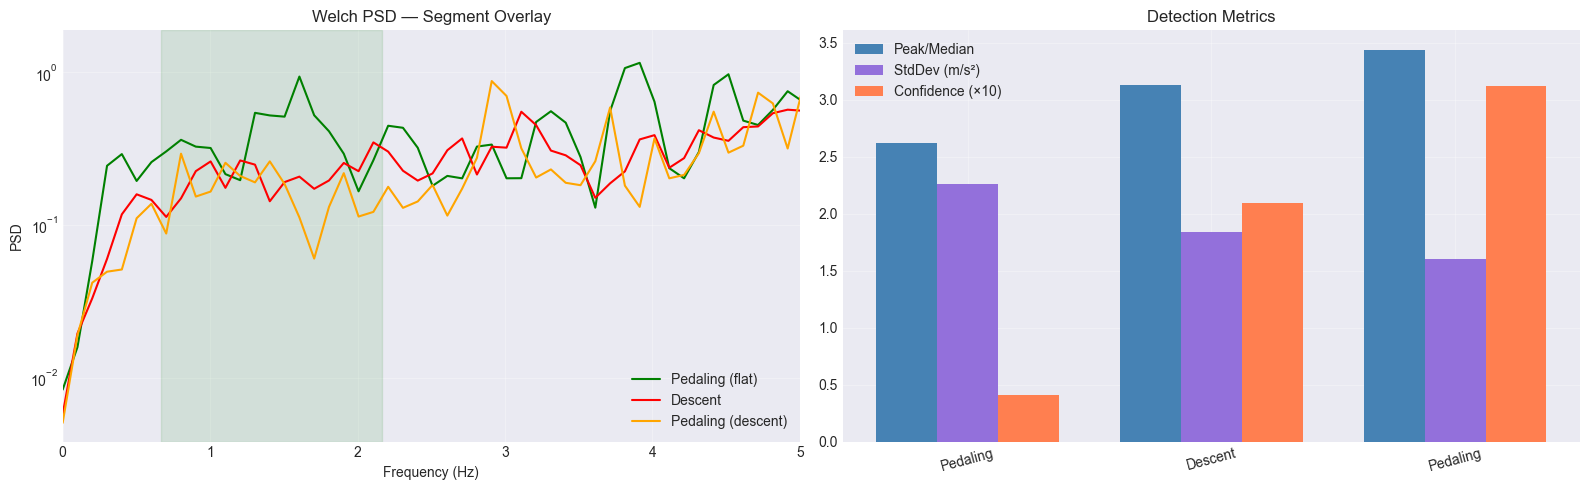

Segment                 Cadence   Conf     Method    P/M  StdDev  Effic
---------------------------------------------------------------------------
Pedaling (flat)          97 RPM  0.041    M1_road   2.62   2.259  72.5%
Descent                 126 RPM  0.209    M1_road   3.13   1.839  76.8%
Pedaling (descent)       50 RPM  0.313    M1_road   3.44   1.602  79.4%


In [15]:
segment_defs = [
    (SEGMENT_PEDALING_FLAT, 'Pedaling (flat)', 'green'),
    (SEGMENT_DESCENT, 'Descent', 'red'),
    (SEGMENT_PEDALING_DESCENT, 'Pedaling (descent)', 'orange'),
]

fig, (ax_psd, ax_bar) = plt.subplots(1, 2, figsize=(16, 5))

results = {}
for (seg, label, color) in segment_defs:
    seg_sig = get_segment_hpf(seg)
    if len(seg_sig) < MIN_FFT_SAMPLES:
        print(f'WARNING: {label} segment too short ({len(seg_sig)} samples), skipping')
        continue

    # Welch PSD overlay
    f, Pxx = scipy_signal.welch(seg_sig, fs=sample_rate, nperseg=min(len(seg_sig), nperseg))
    ax_psd.semilogy(f, Pxx, color=color, linewidth=1.5, label=label)

    # Run pipeline
    r = run_pipeline(seg_sig, sample_rate)
    results[label] = r

ax_psd.axvspan(cadence_band[0], cadence_band[1], alpha=0.1, color='green')
ax_psd.set_xlim(0, 5)
ax_psd.set_xlabel('Frequency (Hz)')
ax_psd.set_ylabel('PSD')
ax_psd.set_title('Welch PSD — Segment Overlay')
ax_psd.legend()
ax_psd.grid(True, alpha=0.3)

# Bar chart: peak-to-median, stddev, confidence
labels_short = list(results.keys())
x = np.arange(len(labels_short))
width = 0.25
colors_bar = ['green', 'red', 'orange'][:len(labels_short)]

ptm = [results[l]['peak_to_median'] for l in labels_short]
std = [results[l]['stddev'] for l in labels_short]
conf = [results[l]['confidence'] * 10 for l in labels_short]  # scale for visibility

ax_bar.bar(x - width, ptm, width, label='Peak/Median', color='steelblue')
ax_bar.bar(x, std, width, label='StdDev (m/s²)', color='mediumpurple')
ax_bar.bar(x + width, conf, width, label='Confidence (×10)', color='coral')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([l.split('(')[0].strip() for l in labels_short], rotation=15)
ax_bar.set_title('Detection Metrics')
ax_bar.legend()
ax_bar.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Segment":<22} {"Cadence":>8} {"Conf":>6} {"Method":>10} {"P/M":>6} {"StdDev":>7} {"Effic":>6}')
print('-' * 75)
for label, r in results.items():
    cad = f"{r['cadence']:.0f} RPM" if r['cadence'] else '—'
    print(f"{label:<22} {cad:>8} {r['confidence']:>6.3f} {r['method']:>10} {r['peak_to_median']:>6.2f} {r['stddev']:>7.3f} {r['efficiency']:>6.1%}")

## Section 6: Rolling Spectrogram

Shows pedaling frequency appearing/disappearing over the ride, with road noise visible as broadband energy.

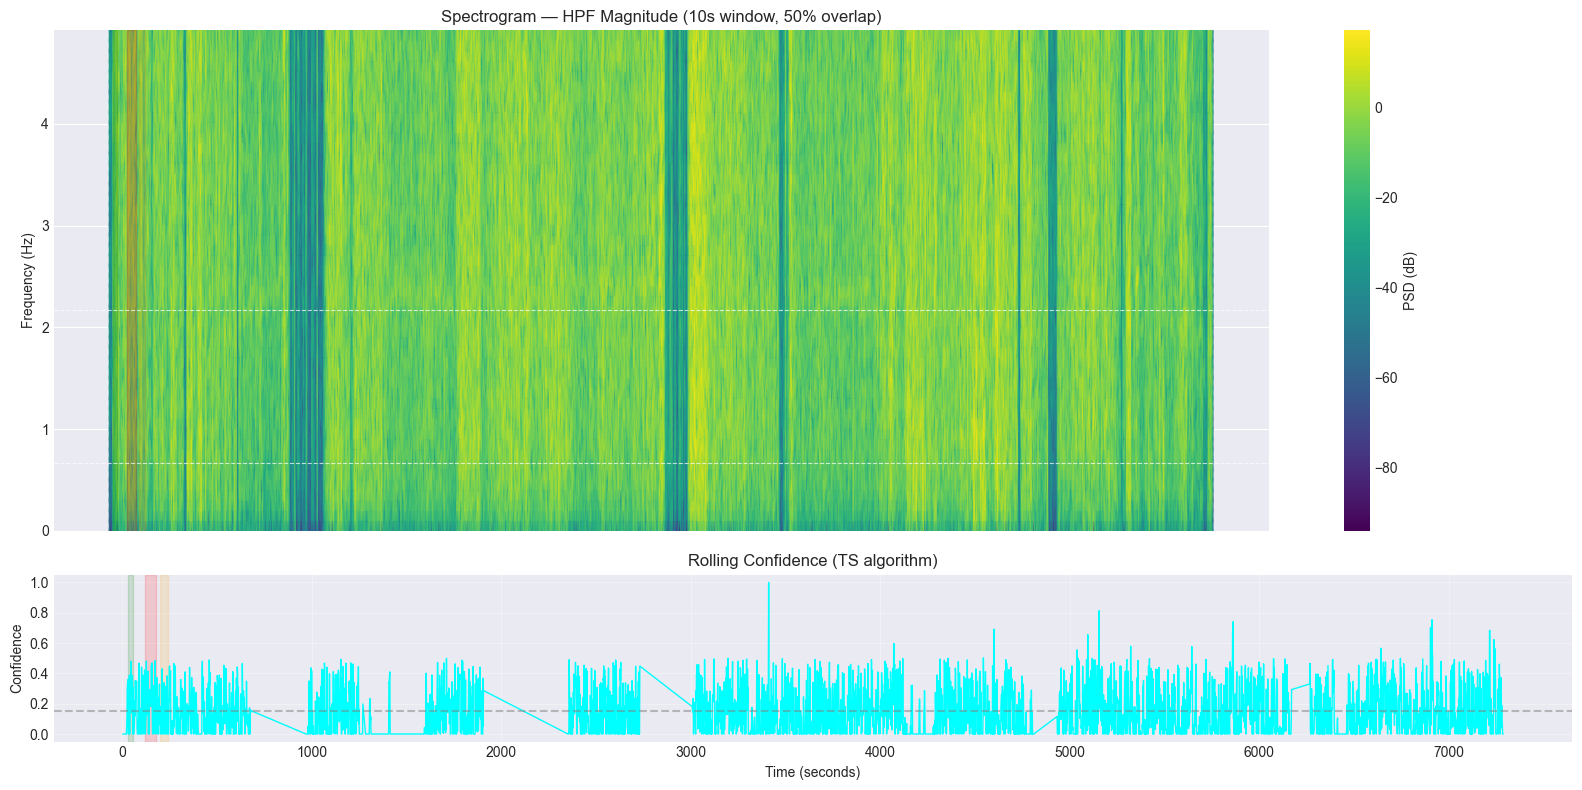

In [16]:
spec_nperseg = int(FFT_WINDOW_SECONDS * sample_rate)
f_spec, t_spec, Sxx = scipy_signal.spectrogram(
    hpf_mag, fs=sample_rate,
    nperseg=spec_nperseg, noverlap=spec_nperseg // 2,
    mode='psd'
)

# Limit to 0–5 Hz
freq_mask = f_spec <= 5.0
f_spec = f_spec[freq_mask]
Sxx = Sxx[freq_mask, :]

fig, (ax_spec, ax_conf) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                        gridspec_kw={'height_ratios': [3, 1]})

# Spectrogram
im = ax_spec.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12),
                         shading='gouraud', cmap='viridis')
ax_spec.axhline(y=cadence_band[0], color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax_spec.axhline(y=cadence_band[1], color='white', linestyle='--', linewidth=0.8, alpha=0.7)
ax_spec.set_ylabel('Frequency (Hz)')
ax_spec.set_title(f'Spectrogram — HPF Magnitude ({FFT_WINDOW_SECONDS}s window, 50% overlap)')
plt.colorbar(im, ax=ax_spec, label='PSD (dB)')

# Shade segments on spectrogram
for (seg, color, label) in [(SEGMENT_PEDALING_FLAT, 'green', 'Flat'),
                              (SEGMENT_DESCENT, 'red', 'Descent'),
                              (SEGMENT_PEDALING_DESCENT, 'orange', 'Ped+Desc')]:
    ax_spec.axvspan(seg[0], seg[1], alpha=0.2, color=color)

# Rolling confidence (computed in next section, preview here with coarse step)
step_samples = int(2.0 * sample_rate)  # 2s step for spectrogram preview
win_samples = int(FFT_WINDOW_SECONDS * sample_rate)
conf_times = []
conf_values = []

for start_idx in range(0, len(hpf_mag) - win_samples, step_samples):
    window = hpf_mag[start_idx:start_idx + win_samples]
    t_center = df['time_sec'].iloc[start_idx + win_samples // 2]
    r = run_pipeline(window, sample_rate)
    conf_times.append(t_center)
    conf_values.append(r['confidence'])

ax_conf.plot(conf_times, conf_values, color='cyan', linewidth=1)
ax_conf.axhline(y=CONFIDENCE_THRESHOLD, color='gray', linestyle='--', alpha=0.5)
ax_conf.set_ylabel('Confidence')
ax_conf.set_xlabel('Time (seconds)')
ax_conf.set_ylim(-0.05, 1.05)
ax_conf.set_title('Rolling Confidence (TS algorithm)')
ax_conf.grid(True, alpha=0.3)

for (seg, color, _) in [(SEGMENT_PEDALING_FLAT, 'green', ''),
                          (SEGMENT_DESCENT, 'red', ''),
                          (SEGMENT_PEDALING_DESCENT, 'orange', '')]:
    ax_conf.axvspan(seg[0], seg[1], alpha=0.15, color=color)

plt.tight_layout()
plt.show()

## Section 7: Cadence Confidence Over Time

Rolling window analysis: 10s FFT window, 1s step across entire recording.

In [17]:
# Rolling analysis with 1s step
step_sec = 1.0
step_samples = int(step_sec * sample_rate)
win_samples = int(FFT_WINDOW_SECONDS * sample_rate)

rolling = {'time': [], 'confidence': [], 'cadence': [], 'method': [],
           'peak_to_median': [], 'stddev': [], 'efficiency': [], 'y_stddev': []}

for start_idx in range(0, len(hpf_mag) - win_samples, step_samples):
    end_idx = start_idx + win_samples
    window = hpf_mag[start_idx:end_idx]
    t_center = df['time_sec'].iloc[start_idx + win_samples // 2]

    r = run_pipeline(window, sample_rate)

    # Y-axis stddev for position detection
    y_window = hpf_y[start_idx:end_idx]
    y_std = np.sqrt(np.mean(y_window ** 2))

    rolling['time'].append(t_center)
    rolling['confidence'].append(r['confidence'])
    rolling['cadence'].append(r['cadence'])
    rolling['method'].append(r['method'])
    rolling['peak_to_median'].append(r['peak_to_median'])
    rolling['stddev'].append(r['stddev'])
    rolling['efficiency'].append(r['efficiency'])
    rolling['y_stddev'].append(y_std)

roll_df = pd.DataFrame(rolling)
print(f'Rolling analysis: {len(roll_df)} windows ({step_sec}s step, {FFT_WINDOW_SECONDS}s window)')
print(f'Methods triggered: {roll_df["method"].value_counts().to_dict()}')

Rolling analysis: 7655 windows (1.0s step, 10s window)
Methods triggered: {'M2_mtb': 3182, 'none': 1962, 'M1_road': 1673, 'M3_rough': 458, 'stationary': 380}


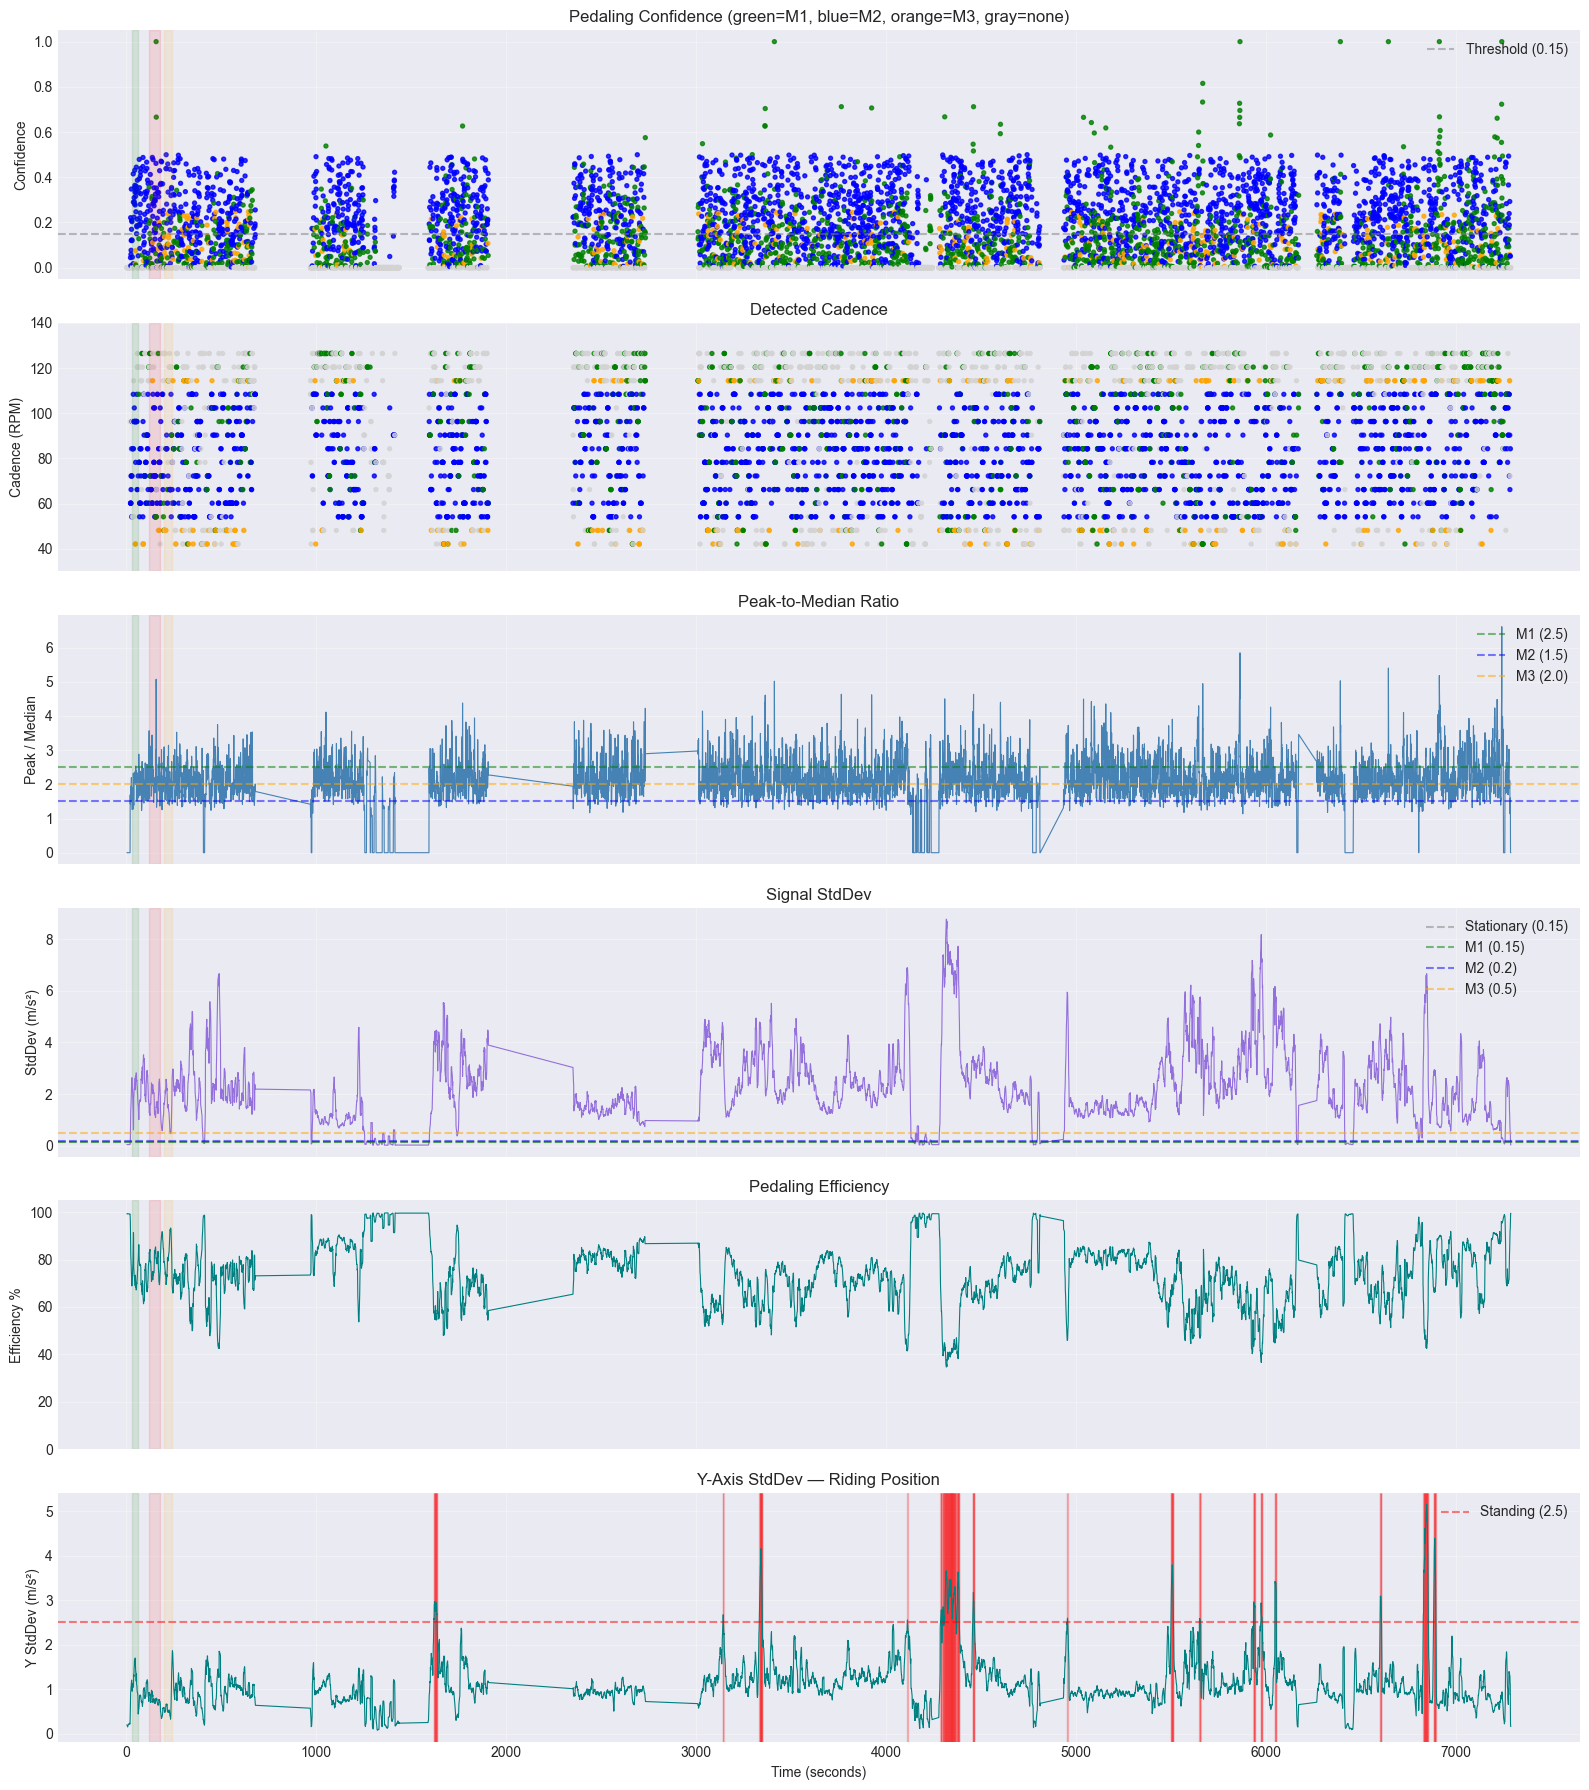

In [18]:
method_colors = {'M1_road': 'green', 'M2_mtb': 'blue', 'M3_rough': 'orange', 'none': 'lightgray',
                 'stationary': 'lightgray', 'too_few_samples': 'lightgray', 'no_spectrum': 'lightgray'}
scatter_c = [method_colors.get(m, 'gray') for m in roll_df['method']]

fig, axes = plt.subplots(6, 1, figsize=(16, 18), sharex=True)

# Panel 1: Confidence colored by method
axes[0].scatter(roll_df['time'], roll_df['confidence'], c=scatter_c, s=8, alpha=0.8)
axes[0].axhline(y=CONFIDENCE_THRESHOLD, color='gray', linestyle='--', alpha=0.5, label=f'Threshold ({CONFIDENCE_THRESHOLD})')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Pedaling Confidence (green=M1, blue=M2, orange=M3, gray=none)')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc='upper right')

# Panel 2: Detected cadence
cad_mask = roll_df['cadence'].notna()
cad_colors = [method_colors.get(m, 'gray') for m in roll_df.loc[cad_mask, 'method']]
axes[1].scatter(roll_df.loc[cad_mask, 'time'], roll_df.loc[cad_mask, 'cadence'],
                c=cad_colors, s=8, alpha=0.8)
axes[1].set_ylabel('Cadence (RPM)')
axes[1].set_title('Detected Cadence')
axes[1].set_ylim(MIN_CADENCE_RPM - 10, MAX_CADENCE_RPM + 10)

# Panel 3: Peak-to-median with method thresholds
axes[2].plot(roll_df['time'], roll_df['peak_to_median'], color='steelblue', linewidth=0.8)
axes[2].axhline(y=METHOD_1_PEAK_TO_MEDIAN, color='green', linestyle='--', alpha=0.5, label=f'M1 ({METHOD_1_PEAK_TO_MEDIAN})')
axes[2].axhline(y=METHOD_2_PEAK_TO_MEDIAN, color='blue', linestyle='--', alpha=0.5, label=f'M2 ({METHOD_2_PEAK_TO_MEDIAN})')
axes[2].axhline(y=METHOD_3_PEAK_TO_MEDIAN, color='orange', linestyle='--', alpha=0.5, label=f'M3 ({METHOD_3_PEAK_TO_MEDIAN})')
axes[2].set_ylabel('Peak / Median')
axes[2].set_title('Peak-to-Median Ratio')
axes[2].legend(loc='upper right')

# Panel 4: StdDev with method thresholds
axes[3].plot(roll_df['time'], roll_df['stddev'], color='mediumpurple', linewidth=0.8)
axes[3].axhline(y=STATIONARY_THRESHOLD, color='gray', linestyle='--', alpha=0.5, label=f'Stationary ({STATIONARY_THRESHOLD})')
axes[3].axhline(y=METHOD_1_MIN_STDDEV, color='green', linestyle='--', alpha=0.5, label=f'M1 ({METHOD_1_MIN_STDDEV})')
axes[3].axhline(y=METHOD_2_MIN_STDDEV, color='blue', linestyle='--', alpha=0.5, label=f'M2 ({METHOD_2_MIN_STDDEV})')
axes[3].axhline(y=METHOD_3_MIN_STDDEV, color='orange', linestyle='--', alpha=0.5, label=f'M3 ({METHOD_3_MIN_STDDEV})')
axes[3].set_ylabel('StdDev (m/s²)')
axes[3].set_title('Signal StdDev')
axes[3].legend(loc='upper right')

# Panel 5: Efficiency
axes[4].plot(roll_df['time'], [e * 100 for e in roll_df['efficiency']], color='teal', linewidth=0.8)
axes[4].set_ylabel('Efficiency %')
axes[4].set_title('Pedaling Efficiency')
axes[4].set_ylim(0, 105)

# Panel 6: Y-axis stddev + position
axes[5].plot(roll_df['time'], roll_df['y_stddev'], color='teal', linewidth=0.8)
axes[5].axhline(y=Y_AXIS_STANDING_THRESHOLD, color='red', linestyle='--', alpha=0.5, label=f'Standing ({Y_AXIS_STANDING_THRESHOLD})')
axes[5].set_ylabel('Y StdDev (m/s²)')
axes[5].set_xlabel('Time (seconds)')
axes[5].set_title('Y-Axis StdDev — Riding Position')
axes[5].legend(loc='upper right')

# Fill standing regions
standing_mask = np.array(roll_df['y_stddev']) > Y_AXIS_STANDING_THRESHOLD
times = np.array(roll_df['time'])
for i in range(len(standing_mask)):
    if standing_mask[i]:
        t = times[i]
        axes[5].axvspan(t - step_sec/2, t + step_sec/2, alpha=0.1, color='red')

# Shade segments on all panels
for ax in axes:
    for (seg, color, label) in [(SEGMENT_PEDALING_FLAT, 'green', ''),
                                 (SEGMENT_DESCENT, 'red', ''),
                                 (SEGMENT_PEDALING_DESCENT, 'orange', '')]:
        ax.axvspan(seg[0], seg[1], alpha=0.1, color=color)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Side-by-Side Segment Comparison

Detailed comparison of any two segments.

In [19]:
def compare_segments(range_a, range_b, label_a='Segment A', label_b='Segment B'):
    """
    Side-by-side 2-column comparison of two time segments.
    4 rows: time domain, Welch PSD, DFT cadence band, metrics text.
    """
    fig = plt.figure(figsize=(16, 16))
    gs = gridspec.GridSpec(4, 2, hspace=0.35, wspace=0.3)

    for col, (seg, label) in enumerate([(range_a, label_a), (range_b, label_b)]):
        mask = (df['time_sec'] >= seg[0]) & (df['time_sec'] < seg[1])
        t = df.loc[mask, 'time_sec'].values
        raw = df.loc[mask, 'accel_mag'].values
        hpf = hpf_mag[mask.values]

        result = run_pipeline(hpf, sample_rate)

        # Row 1: Time domain
        ax1 = fig.add_subplot(gs[0, col])
        ax1.plot(t, raw, linewidth=0.5, alpha=0.5, color='gray', label='Raw')
        ax1.plot(t, hpf, linewidth=0.8, color='steelblue', label='HPF')
        ax1.set_title(f'{label} — Time Domain')
        ax1.set_ylabel('Accel (m/s²)')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.grid(True, alpha=0.3)

        # Row 2: Welch PSD
        ax2 = fig.add_subplot(gs[1, col])
        seg_nperseg = min(len(hpf), nperseg)
        f, Pxx = scipy_signal.welch(hpf, fs=sample_rate, nperseg=seg_nperseg)
        ax2.semilogy(f, Pxx, color='steelblue', linewidth=1)
        ax2.axvspan(cadence_band[0], cadence_band[1], alpha=0.15, color='green')
        ax2.set_xlim(0, 5)
        ax2.set_title(f'{label} — Welch PSD')
        ax2.set_ylabel('PSD')
        ax2.grid(True, alpha=0.3)

        # Row 3: DFT power in cadence band (bar chart in RPM)
        ax3 = fig.add_subplot(gs[2, col])
        if 'freqs' in result and result['freqs'] is not None:
            rpm = result['freqs'] * 60
            ax3.bar(rpm, result['powers'], width=1.5, color='steelblue', alpha=0.8)
            if result['cadence']:
                ax3.axvline(x=result['cadence'], color='red', linestyle='--', linewidth=1, label=f"Peak: {result['cadence']:.0f} RPM")
                ax3.legend(fontsize=8)
        ax3.set_xlim(MIN_CADENCE_RPM - 5, MAX_CADENCE_RPM + 5)
        ax3.set_title(f'{label} — DFT Cadence Band')
        ax3.set_xlabel('Cadence (RPM)')
        ax3.set_ylabel('Power')
        ax3.grid(True, alpha=0.3)

        # Row 4: Metrics text
        ax4 = fig.add_subplot(gs[3, col])
        ax4.axis('off')
        cad_str = f"{result['cadence']:.0f} RPM" if result['cadence'] else '—'
        text = (
            f"Cadence:        {cad_str}\n"
            f"Confidence:     {result['confidence']:.3f}\n"
            f"Method:         {result['method']}\n"
            f"Peak/Median:    {result['peak_to_median']:.2f}\n"
            f"StdDev:         {result['stddev']:.3f} m/s²\n"
            f"Peak Power:     {result['peak_power']:.4f}\n"
            f"Median Power:   {result['median_power']:.4f}\n"
            f"Avg Power:      {result['avg_power']:.4f}\n"
            f"Efficiency:     {result['efficiency']:.1%}"
        )
        ax4.text(0.1, 0.9, text, transform=ax4.transAxes, fontsize=11,
                 verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax4.set_title(f'{label} — Metrics')

    plt.suptitle('Segment Comparison', fontsize=14, y=1.01)
    plt.show()

print('compare_segments() defined.')

compare_segments() defined.


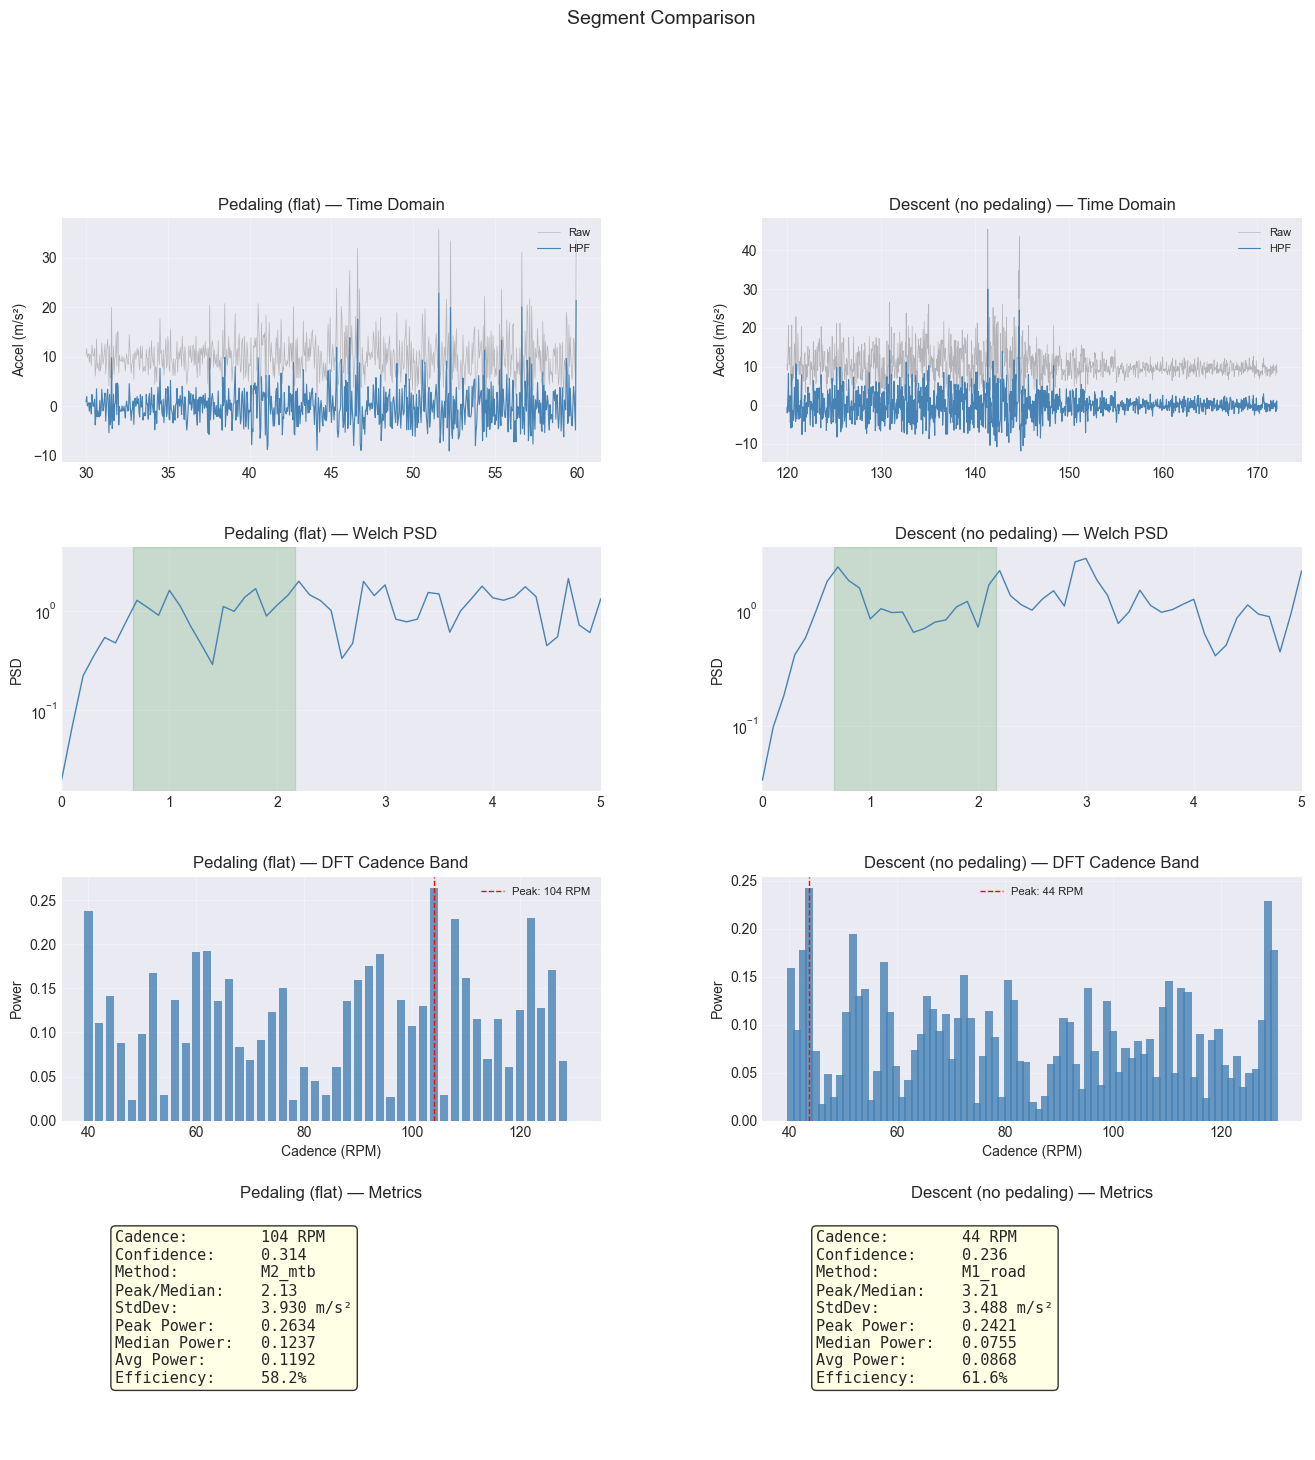

In [15]:
compare_segments(SEGMENT_PEDALING_FLAT, SEGMENT_DESCENT,
                 'Pedaling (flat)', 'Descent (no pedaling)')

/Users/bhawthorne/dev/vertex/venv-analysis/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/bhawthorne/dev/vertex/venv-analysis/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


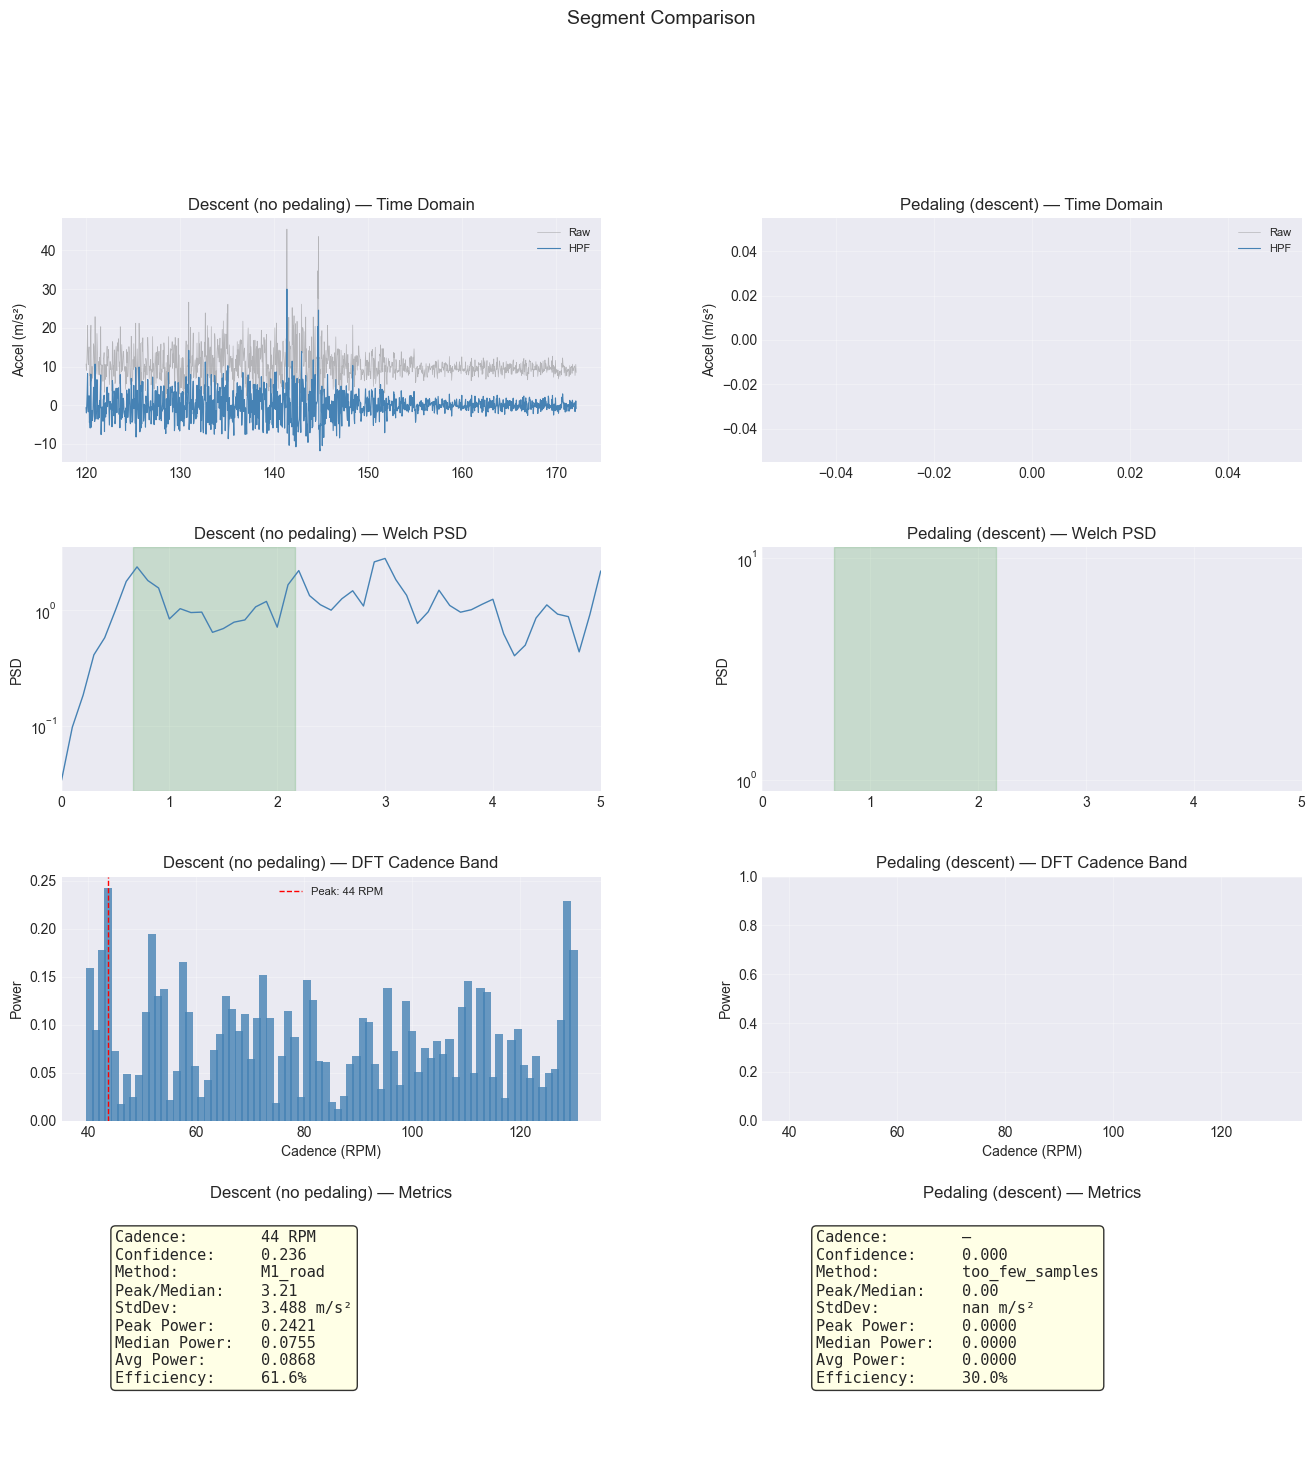

In [16]:
compare_segments(SEGMENT_DESCENT, SEGMENT_PEDALING_DESCENT,
                 'Descent (no pedaling)', 'Pedaling (descent)')

## Section 9: Parameter Tuning Sandbox

Override thresholds and see how confidence changes across the recording.

In [17]:
# ============================================
# TUNING OVERRIDES — edit these to experiment
# ============================================
TUNE_METHOD_1_PEAK_TO_MEDIAN = METHOD_1_PEAK_TO_MEDIAN  # default: 2.5
TUNE_METHOD_2_PEAK_TO_MEDIAN = METHOD_2_PEAK_TO_MEDIAN  # default: 1.5
TUNE_METHOD_3_PEAK_TO_MEDIAN = METHOD_3_PEAK_TO_MEDIAN  # default: 2.0
TUNE_METHOD_3_MIN_STDDEV = METHOD_3_MIN_STDDEV           # default: 0.5
TUNE_METHOD_3_MAX_CONFIDENCE = METHOD_3_MAX_CONFIDENCE   # default: 0.4
TUNE_STATIONARY_THRESHOLD = STATIONARY_THRESHOLD         # default: 0.15
TUNE_METHOD_2_MIN_STDDEV = METHOD_2_MIN_STDDEV           # default: 0.2


def calculate_confidence_tuned(peak_to_median, stddev, cadence):
    """Same as calculate_confidence but using TUNE_* overrides."""
    # Method 1
    if peak_to_median > TUNE_METHOD_1_PEAK_TO_MEDIAN and stddev > METHOD_1_MIN_STDDEV:
        confidence = min(1.0, (peak_to_median - TUNE_METHOD_1_PEAK_TO_MEDIAN) / 3.0)
        if peak_to_median > METHOD_1_STRONG_PEAK_THRESHOLD:
            confidence = min(1.0, confidence + METHOD_1_STRONG_PEAK_BONUS)
        return confidence, 'M1_road'

    # Method 2
    if (peak_to_median > TUNE_METHOD_2_PEAK_TO_MEDIAN and
            stddev > TUNE_METHOD_2_MIN_STDDEV and
            cadence is not None and
            METHOD_2_MIN_CADENCE <= cadence <= METHOD_2_MAX_CADENCE):
        confidence = min(METHOD_2_MAX_CONFIDENCE, (peak_to_median - TUNE_METHOD_2_PEAK_TO_MEDIAN) / 2.0)
        return confidence, 'M2_mtb'

    # Method 3
    if (stddev > TUNE_METHOD_3_MIN_STDDEV and
            peak_to_median > TUNE_METHOD_3_PEAK_TO_MEDIAN and
            cadence is not None and
            METHOD_3_MIN_CADENCE <= cadence <= METHOD_3_MAX_CADENCE):
        confidence = min(TUNE_METHOD_3_MAX_CONFIDENCE, (peak_to_median - TUNE_METHOD_3_PEAK_TO_MEDIAN) / 2.0)
        return confidence, 'M3_rough'

    return 0.0, 'none'


def run_pipeline_tuned(signal_data, sample_rate):
    """Pipeline using tuned confidence function."""
    variance = np.mean(signal_data ** 2)
    stddev = np.sqrt(variance)

    if stddev < TUNE_STATIONARY_THRESHOLD or len(signal_data) < MIN_FFT_SAMPLES:
        return {'confidence': 0.0, 'cadence': None, 'method': 'none'}

    freqs, powers = compute_cadence_dft_fast(signal_data, sample_rate)
    if len(freqs) == 0:
        return {'confidence': 0.0, 'cadence': None, 'method': 'none'}

    peak_idx, peak_power, median_power, avg_power = analyze_spectrum_stats(freqs, powers)
    peak_to_median = peak_power / median_power if median_power > 0 else 0.0
    cadence = freqs[peak_idx] * 60.0 if peak_idx < len(freqs) else None
    confidence, method = calculate_confidence_tuned(peak_to_median, stddev, cadence)

    return {'confidence': confidence, 'cadence': cadence, 'method': method}


# Re-run rolling analysis with tuned params
tuned_conf = []
tuned_method = []

for start_idx in range(0, len(hpf_mag) - win_samples, step_samples):
    window = hpf_mag[start_idx:start_idx + win_samples]
    r = run_pipeline_tuned(window, sample_rate)
    tuned_conf.append(r['confidence'])
    tuned_method.append(r['method'])

roll_df['tuned_confidence'] = tuned_conf
roll_df['tuned_method'] = tuned_method

# Compare
orig_positive = (roll_df['confidence'] >= CONFIDENCE_THRESHOLD).sum()
tuned_positive = (roll_df['tuned_confidence'] >= CONFIDENCE_THRESHOLD).sum()
eliminated = orig_positive - tuned_positive

print(f'Original: {orig_positive} windows above threshold')
print(f'Tuned:    {tuned_positive} windows above threshold')
print(f'Change:   {eliminated:+d} ({eliminated/max(orig_positive,1)*100:+.1f}%)')
print(f'\nTuned method counts: {roll_df["tuned_method"].value_counts().to_dict()}')

Original: 61 windows above threshold
Tuned:    61 windows above threshold
Change:   +0 (+0.0%)

Tuned method counts: {'M2_mtb': 62, 'none': 53, 'M1_road': 42, 'M3_rough': 11}


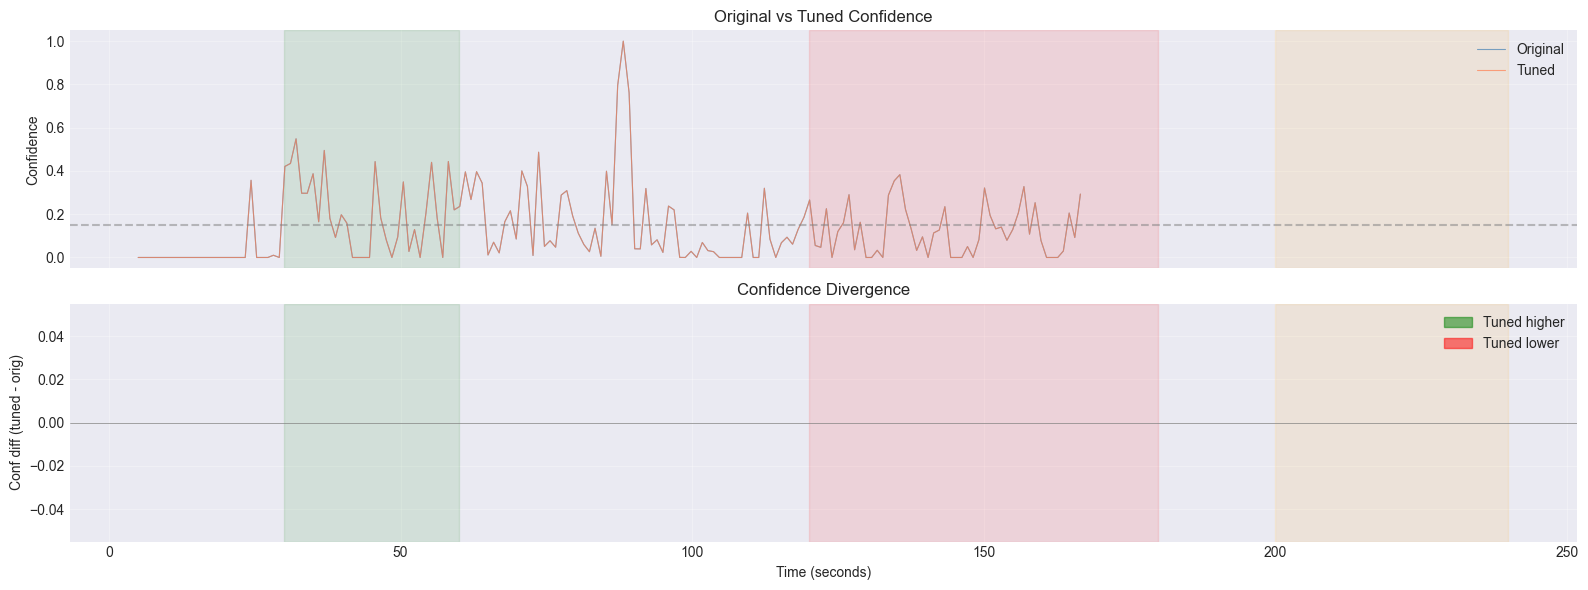


Descent segment (false positives):
  Original: 17 / 49 windows
  Tuned:    17 / 49 windows

Pedaling segment (true positives):
  Original: 19 / 31 windows
  Tuned:    19 / 31 windows


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# Original vs tuned confidence
axes[0].plot(roll_df['time'], roll_df['confidence'], color='steelblue', linewidth=0.8, label='Original', alpha=0.7)
axes[0].plot(roll_df['time'], roll_df['tuned_confidence'], color='coral', linewidth=0.8, label='Tuned', alpha=0.7)
axes[0].axhline(y=CONFIDENCE_THRESHOLD, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Confidence')
axes[0].set_title('Original vs Tuned Confidence')
axes[0].legend(loc='upper right')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

# Divergence: where they differ
diff = np.array(roll_df['tuned_confidence']) - np.array(roll_df['confidence'])
axes[1].fill_between(roll_df['time'], diff, 0, where=diff > 0, color='green', alpha=0.5, label='Tuned higher')
axes[1].fill_between(roll_df['time'], diff, 0, where=diff < 0, color='red', alpha=0.5, label='Tuned lower')
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].set_ylabel('Conf diff (tuned - orig)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Confidence Divergence')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Shade segments
for ax in axes:
    for (seg, color) in [(SEGMENT_PEDALING_FLAT, 'green'), (SEGMENT_DESCENT, 'red'),
                          (SEGMENT_PEDALING_DESCENT, 'orange')]:
        ax.axvspan(seg[0], seg[1], alpha=0.1, color=color)

plt.tight_layout()
plt.show()

# Detailed false positive / true positive analysis in descent segment
descent_mask = (roll_df['time'] >= SEGMENT_DESCENT[0]) & (roll_df['time'] <= SEGMENT_DESCENT[1])
orig_fp = ((roll_df.loc[descent_mask, 'confidence'] >= CONFIDENCE_THRESHOLD)).sum()
tuned_fp = ((roll_df.loc[descent_mask, 'tuned_confidence'] >= CONFIDENCE_THRESHOLD)).sum()

ped_mask = (roll_df['time'] >= SEGMENT_PEDALING_FLAT[0]) & (roll_df['time'] <= SEGMENT_PEDALING_FLAT[1])
orig_tp = ((roll_df.loc[ped_mask, 'confidence'] >= CONFIDENCE_THRESHOLD)).sum()
tuned_tp = ((roll_df.loc[ped_mask, 'tuned_confidence'] >= CONFIDENCE_THRESHOLD)).sum()

print(f'\nDescent segment (false positives):')
print(f'  Original: {orig_fp} / {descent_mask.sum()} windows')
print(f'  Tuned:    {tuned_fp} / {descent_mask.sum()} windows')
print(f'\nPedaling segment (true positives):')
print(f'  Original: {orig_tp} / {ped_mask.sum()} windows')
print(f'  Tuned:    {tuned_tp} / {ped_mask.sum()} windows')

## Section 10: Findings & Next Steps

### Observations (fill in after running)

- [ ] Descent segment shows broadband noise / false cadence peak at ___ RPM
- [ ] Method ___ triggers false positives during descent
- [ ] Peak-to-median ratio during descent: ___ (vs ___ during pedaling)
- [ ] StdDev during descent: ___ m/s² (vs ___ during pedaling)
- [ ] Spectrogram shows cadence band energy during descent: high / low / scattered

### Hypotheses

1. **Which method triggers false positives?** Method ___
2. **Why?** ___
3. **What threshold change fixes it?** ___
4. **Does the fix break true positives?** ___

### Possible Fix Directions

- **Raise M3 peak-to-median threshold**: Currently 2.0, try 2.5–3.0
- **Add broadband noise detector**: If power is spread evenly across spectrum (low peak-to-median AND low peak-to-average), suppress confidence
- **Incorporate speed**: High speed + high stddev + low peak-to-median = descent, not pedaling
- **Switch HPF type**: EMA HPF has slow rolloff; Butterworth 2nd-order would attenuate road noise better
- **Harmonic check**: Real pedaling has a 2nd harmonic; road noise doesn't — check for harmonic at 2× cadence frequency